In [1]:
import sys
from pathlib import Path

workspace_root = Path.cwd()
while not (workspace_root / "pyproject.toml").exists() and workspace_root != workspace_root.parent:
    workspace_root = workspace_root.parent

if not (workspace_root / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate the QCMet workspace root")

sys.path.insert(0, str(workspace_root))
import matplotlib.pyplot as plt

from qcmet.benchmarks.circuit_execution_quality_metrics.clifford_linear_xeb import CliffordLinearXEB
from qcmet import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
)


In [2]:
n_qubits = 20
depth = 30
num_circuits = 50
seed = 42

In [3]:
experiment = CliffordLinearXEB(
    qubits=n_qubits,
    depth=depth,
    num_circuits=num_circuits,
    seed=seed,
)

experiment.generate_circuits()
experiment.run(
    device=AerSimulator(seed_simulator=seed),
    num_shots=1024
)

experiment.analyze()['mean_fidelity']

1.1

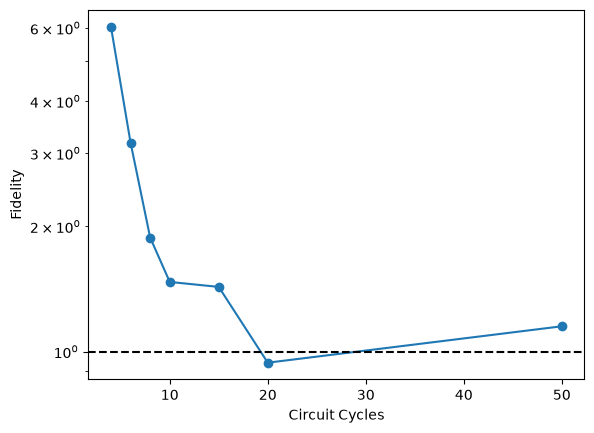

In [ ]:
# fidelity versus circuit depth.
# There should be two phases, a scrambling phase, where the fidelity decreases to ~1 
# due to the randomization of the circuit, and then a decay phase where the fidelity decreases further due to noise accumulation.
n_qubits = 20
num_circuits = 100
seed = 42

depths = [4, 6, 8, 10, 15, 20, 30, 40, 50]  # 
noise = 0.0
fidelities = []

noise_model = NoiseModel()

# one qubit noise
# error = depolarizing_error(noise, 1)
# noise_model.add_all_qubit_quantum_error(error, ["u1", "u2", "u3"])

# two qubit noise
error2 = depolarizing_error(noise, 2)
noise_model.add_all_qubit_quantum_error(error2, ["cz", "cx"])
for depth in depths:
    print(f'Running depth: {depth}')

    noisy_simulator = AerSimulator(
        # noise_model=noise_model,
        # seed_simulator=seed
    )

    experiment = CliffordLinearXEB(
    qubits=n_qubits,
    depth=depth,
    num_circuits=num_circuits,
    seed=seed
    )

    experiment.generate_circuits()
    experiment.run(
        device=noisy_simulator,
        num_shots=1000
    )
    
    fidelities.append(experiment.analyze()['mean_fidelity'])

plt.semilogy(depths, fidelities, 'o-')
plt.axhline(y = 1, color = 'k', linestyle = '--')
plt.xlabel('Circuit Cycles')
plt.ylabel('Fidelity')
plt.show()